<a href="https://colab.research.google.com/github/snehaxavier2110/Mtech_coursework/blob/main/lstm_del.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


In [ ]:
# Load and prepare data
df = pd.read_csv("/content/delhi (1).csv")
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df.set_index('Date', inplace=True)
data = df['AQI'].values.reshape(-1, 1)

In [ ]:
# Scale the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [ ]:
# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

In [ ]:
# Parameters
sequence_length = 24
train_end_date = '01-12-2019'
forecast_date = '25-06-2020'

# Split data
train_data = df.loc[:train_end_date]

# Find the index location of the forecast_date
# Use searchsorted to get an integer index even if the date is not exactly in the index
test_index = df.index.searchsorted(forecast_date)

# Ensure test_index is within the valid range for creating test sequences
if test_index < sequence_length:
    raise ValueError(f"Forecast date is too early to create sequences of length {sequence_length}")

test_sequence_start = test_index - sequence_length

In [ ]:

# Prepare training data
X, y = create_sequences(scaled_data[:len(train_data)], sequence_length)
X_train, y_train = X[:-24], y[:-24]


In [ ]:
# Build and train LSTM model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1), return_sequences=True),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1084
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0196
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0197
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0187
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0174
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0168
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0168
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0160
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0155
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0172
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0154
Epoch 12/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0157
Epoch 13/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0146
Epoch 14/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0142
Epoch 15/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0133
Epoc

In [ ]:
# Generate forecasts for the specific range
forecast_start = 2003
forecast_end = 2008
forecast_length = forecast_end - forecast_start + 1

# Initialize forecast array
lstm_forecasts = np.zeros(forecast_length)

# Generate forecasts one by one
for i in range(forecast_length):
    input_seq = scaled_data[forecast_start + i - sequence_length:forecast_start + i]
    input_seq = input_seq.reshape(1, sequence_length, 1)
    forecast = model.predict(input_seq, verbose=0)
    lstm_forecasts[i] = scaler.inverse_transform(forecast)[0][0]

# Create comparison DataFrame
df['lstm_forecast'] = 0
df['lstm_forecast'].iloc[forecast_start:forecast_end + 1] = lstm_forecasts

# Get actual and forecasted values
comparison = df[['AQI', 'lstm_forecast']].iloc[forecast_start:forecast_end + 1]

# Calculate metrics
mse = mean_squared_error(comparison['AQI'], comparison['lstm_forecast'])
mae = mean_absolute_error(comparison['AQI'], comparison['lstm_forecast'])
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(comparison['AQI'], comparison['lstm_forecast'])

/tmp/ipython-input-3252854632.py:18: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['lstm_forecast'].iloc[forecast_start:forecast_end + 1] = lstm_forecasts
/tmp/ipython-input-3252854632.py:18: SettingWithCopyWarning: 
A value is trying to 

In [ ]:
# Print metrics
print("\nModel Performance Metrics:")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")


Model Performance Metrics:
MSE: 3515.8323
MAE: 47.4246
RMSE: 59.2945
MAPE: 0.3050


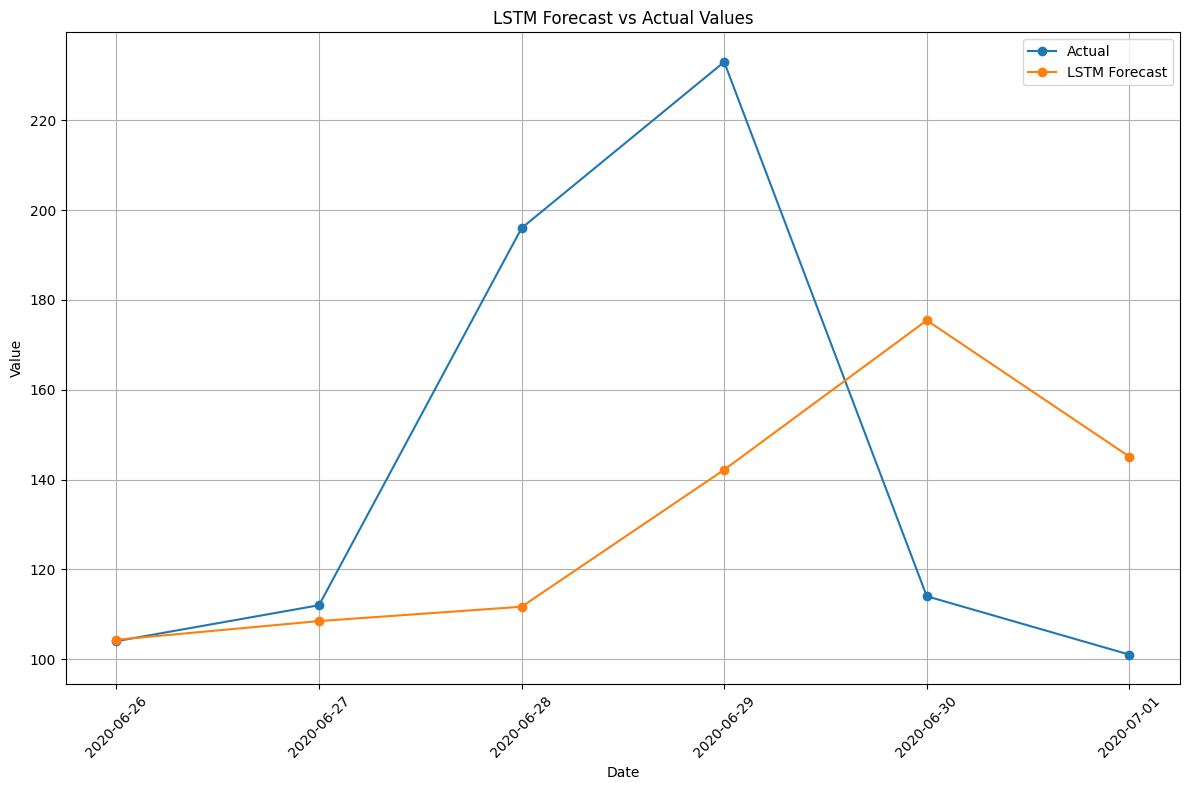

In [ ]:
# Plot results
plt.figure(figsize=(12, 8))
plt.plot(comparison.index, comparison['AQI'], label='Actual', marker='o')
plt.plot(comparison.index, comparison['lstm_forecast'], label='LSTM Forecast', marker='o')
plt.title('LSTM Forecast vs Actual Values')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Save comparison to CSV
comparison.to_csv('AQI_lstm_forecast_comparison.csv')